In [1]:
from app.config import load_config, load_classes
from app.main import get_video_sources
from app.pipeline import run_pipeline
from app.monitoring import load_events, build_summary, print_summary
from app.dashboard import create_dashboard

In [2]:
CONFIG = load_config()
OBJECT_CLASSES = load_classes()

In [3]:
VIDEO_SOURCES = get_video_sources(CONFIG)

print("Sources:")
for i, source in enumerate(VIDEO_SOURCES, start=1):
    print(f"  Camera {i}: {source}")

[INFO] Found 4 video source(s).
Sources:
  Camera 1: videos\10531835-uhd_2160_3840_30fps.mp4
  Camera 2: videos\13395455_2160_3840_60fps.mp4
  Camera 3: videos\sample-5s-720p.mp4
  Camera 4: videos\sample_video.mp4


In [4]:
run_pipeline(VIDEO_SOURCES, CONFIG, OBJECT_CLASSES)

[Camera 3] Producer done | Pushed: 27 | Dropped: 144 | Drop rate: 411.43%
[Camera 4] Producer done | Pushed: 72 | Dropped: 331 | Drop rate: 408.64%
[Worker 1] Cam4 Frame0: No detection
[Worker 1] Cam4 Frame1: No detection
[Worker 1] Cam4 Frame2: No detection
[Worker 1] Cam4 Frame3: No detection
[Worker 1] Cam4 Frame4: No detection
[Worker 1] Cam4 Frame5: No detection
[Worker 1] Cam4 Frame6: No detection
[Worker 1] Cam4 Frame7: No detection
[Worker 1] Cam4 Frame8: No detection
[Worker 1] Cam4 Frame9: No detection
[Worker 1] Cam4 Frame10: No detection
[Worker 1] Cam4 Frame11: No detection
[Worker 1] Cam4 Frame12: No detection
[Worker 1] Cam4 Frame13: No detection
[Worker 1] Cam4 Frame14: No detection
[Camera 1] Producer done | Pushed: 7 | Dropped: 272 | Drop rate: 485.71%
[Worker 1] Cam4 Frame15: No detection
[Worker 1] Cam4 Frame16: No detection
[Worker 1] Cam4 Frame17: No detection
[Worker 1] Cam4 Frame18: No detection
[Worker 1] Cam4 Frame19: No detection
[Worker 1] Cam4 Frame20: No d

In [5]:
LOG_FILE = CONFIG["output"]["log_file"]
events = load_events(LOG_FILE)
camera_data = build_summary(events)
print_summary(camera_data)


PIPELINE MONITORING SUMMARY

Camera 1
  Frames pushed : 7
  Frames dropped: 272
  Drop rate     : 485.70%
  Max queue     : 100
  Max fullness  : 99.0%
  Avg lag       : 70.99 sec
  Max lag       : 73.07 sec
  Detections    : 103

Camera 2
  Frames pushed : 146
  Frames dropped: 1820
  Drop rate     : 461.90%
  Max queue     : 100
  Max fullness  : 99.0%
  Avg lag       : 96.12 sec
  Max lag       : 118.84 sec
  Detections    : 646

Camera 3
  Frames pushed : 27
  Frames dropped: 144
  Drop rate     : 411.40%
  Max queue     : 100
  Max fullness  : 99.0%
  Avg lag       : 68.50 sec
  Max lag       : 85.30 sec
  Detections    : 111

Camera 4
  Frames pushed : 72
  Frames dropped: 331
  Drop rate     : 408.60%
  Max queue     : 100
  Max fullness  : 99.0%
  Avg lag       : 47.75 sec
  Max lag       : 85.90 sec
  Detections    : 41


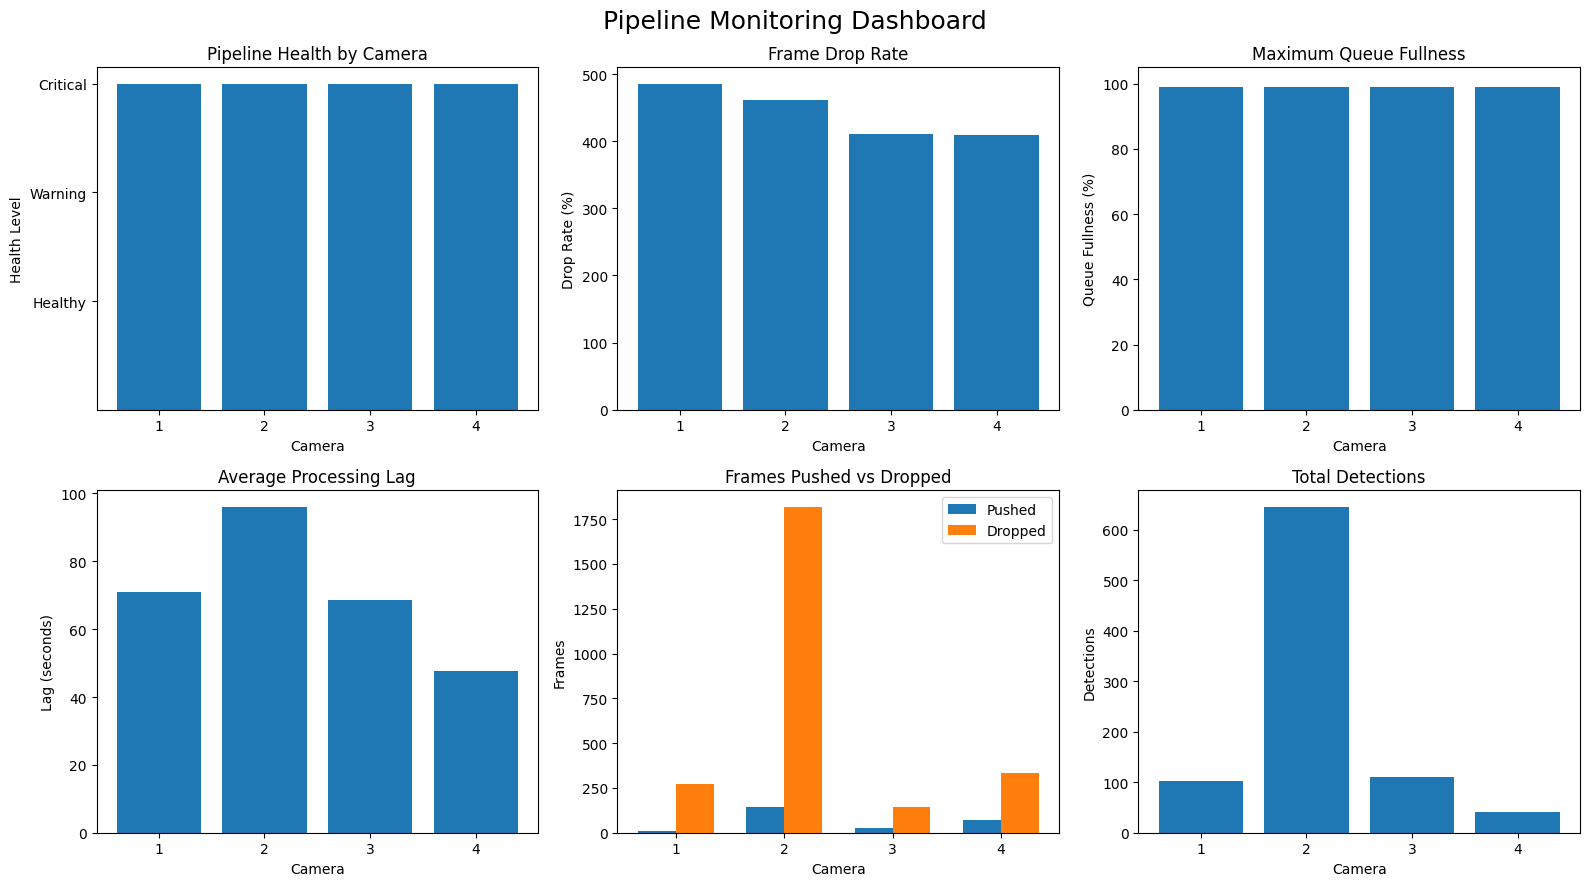

Dashboard saved to: results/pipeline_monitoring_dashboard.png


In [6]:
DASHBOARD_PATH = CONFIG["output"]["dashboard_file"]
create_dashboard(camera_data, DASHBOARD_PATH)